# Course Grade Analysis


1. **Re-run cleaning** (same steps from Part 1, condensed into one cell so this notebook is self-contained)
2. **Grade visualizations** — course-level distributions, co-enrollment grade effects, department comparisons
3. **Predictive models** — similar course finder (NLP) and next-course recommender with expected grade

---
## Section 0 — Setup & Cleaning (condensed from Part 1)

We condense all the cleaning steps here so this notebook runs on its own.
Every decision below mirrors what was done in Part 1 — no new choices.

**What each line does is explained inline with comments.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Standard imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings

# sklearn — used later for TF-IDF (text similarity) and nearest-neighbor prediction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

# itertools / collections — used to count co-enrolled course pairs
from itertools import combinations
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')      # keeps output clean
sns.set_theme(style='whitegrid')       # consistent plot style throughout

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
# ── Load raw CSV ──────────────────────────────────────────────────────────────
# Change this path to wherever your file lives in Google Drive.
# encoding='latin-1' is needed because some course descriptions contain
# non-UTF-8 characters (accented letters, special symbols).
FILE_PATH = '/content/drive/MyDrive/Hackathon - Course Grade /coursework.csv'

df = pd.read_csv(FILE_PATH, encoding='latin-1')

# Normalize column names: strip whitespace, lowercase, replace spaces with _
# This prevents bugs like df['Grade'] vs df['grade']
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

print(f'Loaded {len(df):,} rows with columns: {df.columns.tolist()}')

Loaded 2,785 rows with columns: ['student_id', 'year', 'semester', 'institution', 'course_number', 'credits', 'grade', 'course_description']


In [ ]:
# ── Clean: semester ───────────────────────────────────────────────────────────
# The raw data has typos like 'SPING', 'SUMMMER', trailing spaces.
# We strip whitespace, force uppercase, then map every variant to the
# canonical three values: FALL / SPRING / SUMMER.
# Rows that don't match any key become NaN — we drop those below.

semester_map = {
    'FALL': 'FALL', 'FALL ': 'FALL',
    'SPRING': 'SPRING', 'SPRING ': 'SPRING', 'SPING': 'SPRING', 'SPRNG': 'SPRING',
    'SUMMER': 'SUMMER', 'SUMMER ': 'SUMMER', 'SUMMMER': 'SUMMER',
}
df['semester'] = df['semester'].astype(str).str.strip().str.upper().map(semester_map)

# ── Clean: grade ──────────────────────────────────────────────────────────────
# Strip whitespace, force uppercase, then replace placeholder strings with NaN.
# After that, normalize alternate spellings to the official UT symbol.
df['grade'] = (
    df['grade']
    .astype(str).str.strip().str.upper()
    .replace({'NAN': pd.NA, 'NONE': pd.NA, '': pd.NA, '-': pd.NA, ' ': pd.NA})
)
# A+ does not exist at UT — collapse to A
# Text variants for special grades → official symbols
grade_normalize = {'A+': 'A', 'CREDIT': 'CR', 'IN PROGRESS': 'IP', 'TBD': 'IP', 'NOW': 'IP'}
df['grade'] = df['grade'].replace(grade_normalize)

# ── Derived grade columns ─────────────────────────────────────────────────────
# letter_grade: only actual A/B/C/D/F grades (excludes CR, W, IP etc.)
# These are the grades we can convert to GPA points.
LETTER_GRADES = {'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F'}
df['letter_grade'] = df['grade'].where(df['grade'].isin(LETTER_GRADES))

# grade_points: numeric GPA equivalent so we can compute averages
GPA_MAP = {
    'A': 4.00, 'A-': 3.67, 'B+': 3.33, 'B': 3.00, 'B-': 2.67,
    'C+': 2.33, 'C': 2.00, 'C-': 1.67, 'D+': 1.33, 'D': 1.00, 'D-': 0.67, 'F': 0.00
}
df['grade_points'] = df['letter_grade'].map(GPA_MAP)

# ── Clean: course_number ──────────────────────────────────────────────────────
# Remove spaces and dashes so 'M 408C' and 'M408C' are the same course.
df['course_number'] = (
    df['course_number'].astype(str).str.strip().str.upper()
    .str.replace(r'\s+', '', regex=True)
    .str.replace('-', '', regex=False)
)

# ── Clean: course_number ──────────────────────────────────────────────────────
# Remove spaces and dashes so 'M E 408C', 'M 408C', and 'M408C' all become 'M408C'.
df['course_number'] = (
    df['course_number'].astype(str).str.strip().str.upper()
    .str.replace(r'\s+', '', regex=True)
    .str.replace('-', '', regex=False)
)

# Flag courses with encoding corruption (leftover ?, _, non-alphanumeric chars).
# These rows can't be reliably matched to a department and should be excluded
# from any course-level aggregation.
df['flag_garbled_course'] = df['course_number'].str.contains(r'[^A-Z0-9]', na=False)

# ── Department extraction ─────────────────────────────────────────────────────
# Strategy: longest-prefix match against the official UT department registry.
# This prevents the simple regex from mangling codes like RHE→RH, CHE→CH,
# EVE→EV, ASE→AS (all end in a letter that looks like a section modifier).
#
# Fallback chain:
#   1. Direct match against registry (requires next char to be a digit)
#   2. Strip one trailing modifier char (N/W/F/H/S) from the prefix, retry
#   3. Known alias table for variant abbreviations in the data
#   4. Raw extracted prefix (flagged via dept_in_registry=False)

ut_departments = {
    'A','AI','AAR','AAS','ACC','ACF','ADV','AED','AET','AFR','AFS','AHC','AMS','ANS','ANT','ARA','ARC','ARE',
    'ARH','ARI','ART','ASE','ASL','AST','AUD',
    'BA','BAH','BAX','BCH','BDP','BEN','BGS','BIO','BME',
    'CC','CE','CL','CS','CDI','CGS','CH','CHE','CHI','CIV','CLD','CMS','COE','COM','CON','CRP','CRW','CSE','CTI','CZ',
    'DS','DAN','DCH','DES','DEV','DSC',
    'E','EM','ES','ECE','ECO','EDC','EDP','EDU','EEB','EEE','EER','ELP','EMA','ENM','ENS','ESL','EUS','EVE','EVS',
    'FA','FC','FIN','FR',
    'GE','GEO','GER','GK','GOV','GRG','GRS','GSD',
    'HE','HS','HCT','HDF','HDO','HEB','HED','HHM','HIN','HIS','HMN',
    'I','IB','ILA','INB','INF','IRG','ISP','ITC','ITD','ITL',
    'J','JS','JPN',
    'KIN','KOR',
    'LA','LAH','LAL','LAR','LAS','LAT','LEB','LIN','LTC',
    'M','ME','MS','MAL','MAN','MAS','MBS','MDV','MEL','MES','MFG','MIC','MIS','MKT','MLS','MNS','MOL','MSE','MUS',
    'N','NS','NEU','NOR','NRP','NSC','NSP','NTR',
    'OM','ORI',
    'PA','PB','PL','PR','PS','PBH','PED','PGE','PGS','PHL','PHM','PHY','POL','POR','PPE','PRC','PRF','PRS','PSC','PSF','PSY',
    'RE','RM','RS','RBT','REE','RHE','RIM','ROM','RTF','RUS',
    'SC','SS','SW','SAL','SAN','SCI','SDS','SED','SEL','SLH','SOC','SPB','SPC','SPN','SSE','STA','STC','STM','SUS','SWA','SWE',
    'TC','TD','TAM','TEL','TUR','TXA',
    'UD','UGS','UKR','URB','URD','UTL','UTS',
    'WGS','WRT',
    'YID','YOR'
}

# Longest-first so 'ECE' is checked before 'E', 'ME' before 'M', etc.
ut_departments_sorted = sorted(ut_departments, key=len, reverse=True)

# Known variant abbreviations found in student transcript data → canonical code
dept_aliases = {
    'PHYS': 'PHY',   # alternate Physics abbreviation
    'GOVS': 'GOV',   # GOV with section suffix baked in
    'BMES': 'BME',   # Biomedical Engineering variant
    'EMS':  'EM',    # Engineering Mechanics variant
    'EE':   'ECE',   # old Electrical Engineering abbreviation
}

# Single-character section/variant modifiers that can trail a dept prefix
# e.g. MEW338 (W=writing flag), HISF315 (F=flag course), CSN200 (N=lab section)
modifier_chars = set('NWFHS')

def extract_department(course):
    if pd.isna(course):
        return pd.NA
    s = str(course).strip().upper()

    # Step 1: direct longest-prefix match against official registry
    for dept in ut_departments_sorted:
        if s.startswith(dept) and len(s) > len(dept) and s[len(dept)].isdigit():
            return dept

    # Isolate alpha prefix before the first digit
    m = re.match(r'^([A-Z]+)\d', s)
    if m:
        prefix = m.group(1)
        # Step 2: strip one trailing modifier char and retry registry lookup
        if len(prefix) > 1 and prefix[-1] in modifier_chars:
            trimmed = prefix[:-1]
            if trimmed in ut_departments:
                return trimmed
        # Step 3: alias table
        if prefix in dept_aliases:
            return dept_aliases[prefix]
        # Step 4: fallback — return raw prefix, flagged below
        return prefix

    return pd.NA

df['department'] = df['course_number'].apply(extract_department)
df['dept_in_registry'] = df['department'].isin(ut_departments)

# ── Normalize course_number using the extracted department ────────────────────
# The department extractor already stripped modifier characters (N/W/F/H/S) to
# find the correct dept prefix, but the course_number column itself was never
# corrected. This step uses that result to fix the course_number in place.
#
# e.g. dept='CS', course_number='CSN303E'
#      remainder after dept = 'N303E'  → N is modifier, next char is digit → strip it
#      corrected course_number = 'CS' + '303E' = 'CS303E'

def fix_course_number(course, dept):
    if pd.isna(course) or pd.isna(dept):
        return course
    remainder = str(course)[len(str(dept)):]          # everything after the dept prefix
    if (remainder
            and remainder[0] in modifier_chars        # first char is a known modifier
            and len(remainder) > 1
            and remainder[1].isdigit()):              # second char is a digit (confirms it's a modifier, not part of dept)
        return str(dept) + remainder[1:]              # drop the modifier
    return course

df['course_number'] = df.apply(
    lambda r: fix_course_number(r['course_number'], r['department']), axis=1
)

# Sanity check — confirm the problem cases are fixed
print("Spot check — these should all be gone from course_number:")
problem_cases = ['CSN303E', 'EM319M', 'MEW338', 'MEN134L', 'HISF315K']
found = df[df['course_number'].isin(problem_cases)]['course_number'].unique()
print(f"  Still present: {found if len(found) else 'none ✓'}")

# Also extract the numeric portion — useful for course-level ordering/grouping
df['course_digits'] = df['course_number'].str.extract(r'(\d+)')

# ── Drop rows we cannot use ───────────────────────────────────────────────────
# Garbled courses have no reliable course_number, department, or digits.
# Drop them rather than carry forward bad keys into the models.
df = df.dropna(subset=['semester', 'department'])
df = df[~df['flag_garbled_course']]

# Sanity check
print(f'Rows after cleaning: {len(df):,}')
print(f'Students: {df["student_id"].nunique()}')
print(f'Unique courses: {df["course_number"].nunique()}')
print(f'Unique departments (registry): {df[df["dept_in_registry"]]["department"].nunique()}')
print(f'Departments NOT in registry (check these): {df[~df["dept_in_registry"]]["department"].value_counts().to_dict()}')
print(f'\nGrade distribution (letter grades only):')
print(df['letter_grade'].value_counts())

# ── Drop rows we cannot use ───────────────────────────────────────────────────
# Rows with no semester or no department can't be placed on a timeline or grouped
#df = df.dropna(subset=['semester', 'department'])

# Sanity check
print(f'Rows after cleaning: {len(df):,}')
print(f'Students: {df["student_id"].nunique()}')
print(f'Unique courses: {df["course_number"].nunique()}')
print(f'Unique departments: {df["department"].nunique()}')
print(f'\nGrade distribution (letter grades only):')
print(df['letter_grade'].value_counts())

Spot check — these should all be gone from course_number:
  Still present: ['EM319M']
Rows after cleaning: 2,747
Students: 71
Unique courses: 257
Unique departments (registry): 66
Departments NOT in registry (check these): {'SAB': 4}

Grade distribution (letter grades only):
letter_grade
A     1359
A-     296
B      262
B+     193
B-      79
C       70
C+      40
C-      26
D        4
D-       1
Name: count, dtype: int64
Rows after cleaning: 2,747
Students: 71
Unique courses: 257
Unique departments: 67

Grade distribution (letter grades only):
letter_grade
A     1359
A-     296
B      262
B+     193
B-      79
C       70
C+      40
C-      26
D        4
D-       1
Name: count, dtype: int64


---
## Section 1 — Grade Distribution Visualizations

Now that the data is clean we can start answering visual questions:
- How are grades distributed for each course?
- Does taking certain courses *together* affect your grade?
- Which departments grade hardest / easiest?

### 1A — Per-course grade distribution

Given any course number, show:
- A bar chart of every letter grade received
- Overlay of the cumulative percentage so you can read pass/fail thresholds at a glance
- Printed summary stats: average GPA, pass rate, number of records

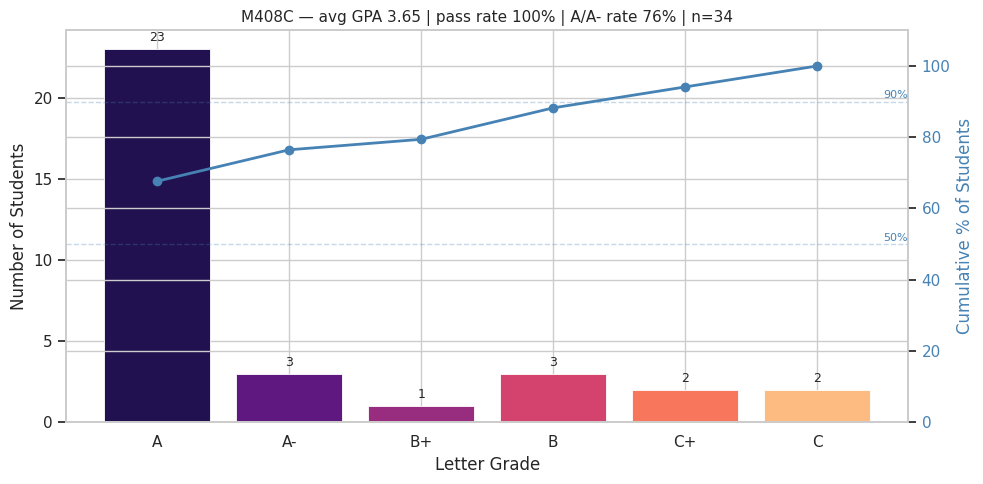

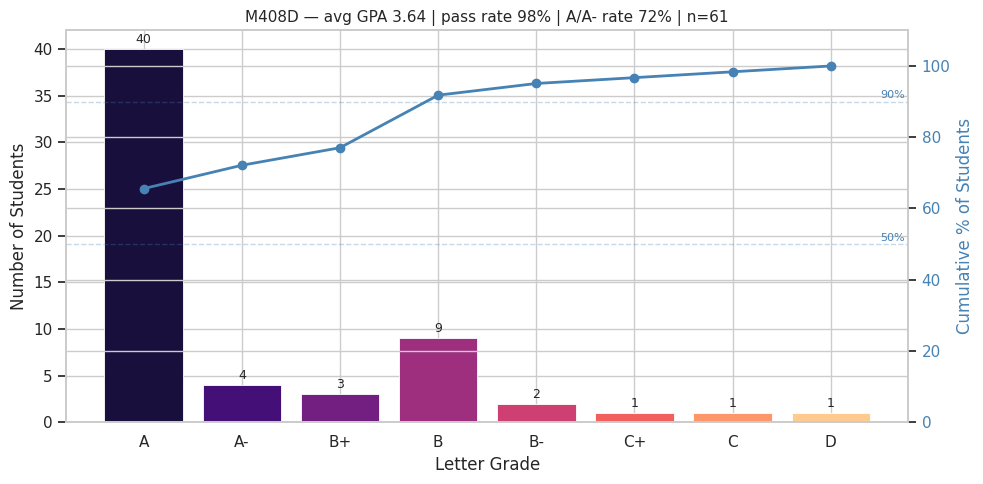

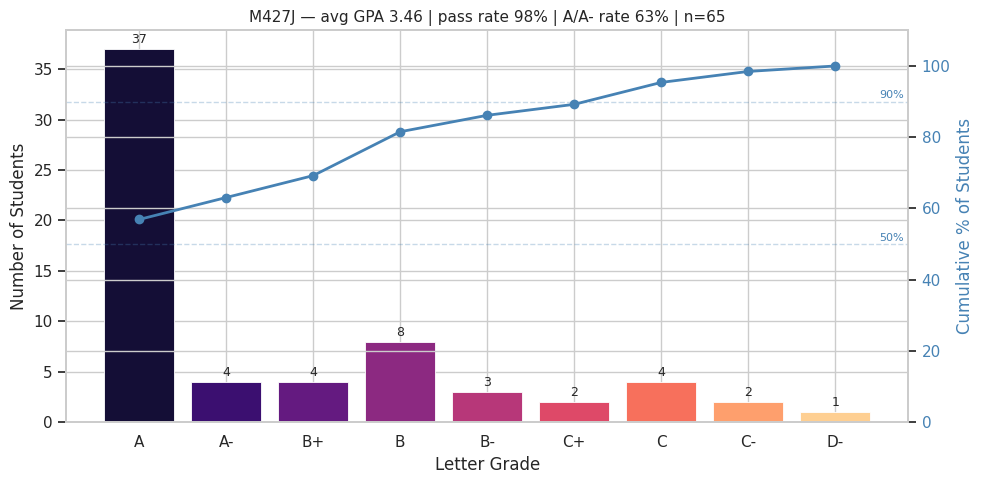

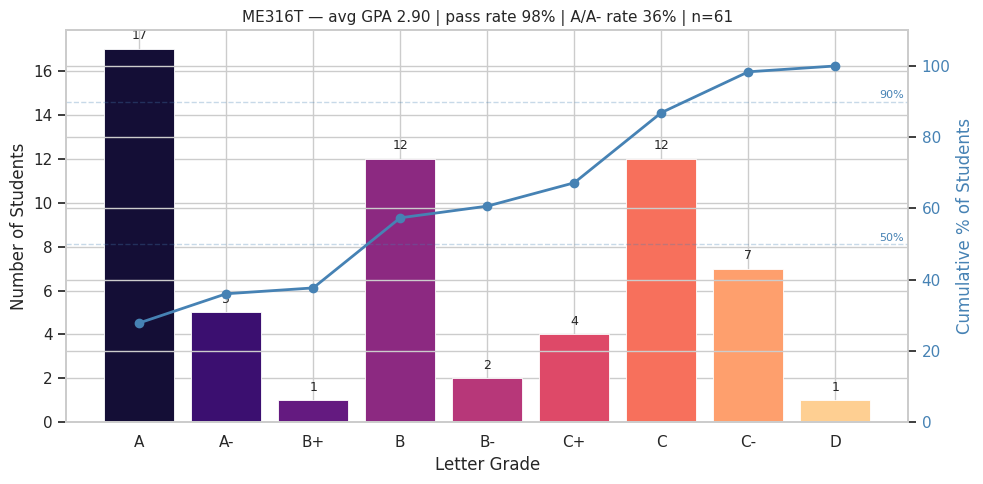

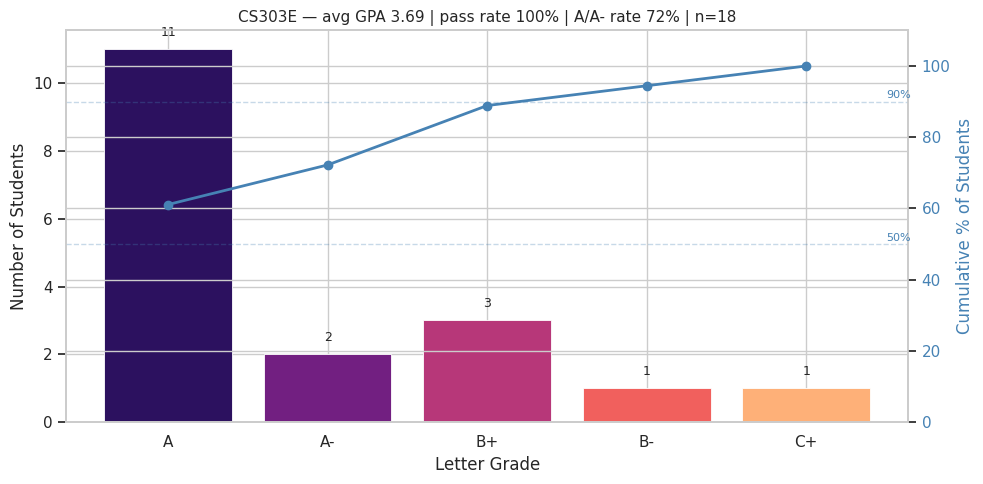

In [ ]:
def plot_course_grade_distribution(course_number):
    """
    Plots the grade distribution bar chart for one course with a
    cumulative-percentage overlay, and prints summary analytics.

    Parameters
    ----------
    course_number : str
        The course code to look up, e.g. 'M408C'.
    """
    # --- Step 1: filter to this course and drop rows with no letter grade ---
    # We only use rows where a real letter grade exists (A through F).
    # CR, W, IP etc. are excluded because they have no GPA meaning.
    course_df = df[df['course_number'] == course_number].copy()
    graded = course_df.dropna(subset=['letter_grade'])

    if graded.empty:
        print(f'No letter grade data found for {course_number}.')
        return

    # --- Step 2: count how many times each grade appeared, in GPA order ---
    # GRADE_ORDER ensures the bars go from best (A) to worst (F) left to right.
    GRADE_ORDER = ['A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F']
    counts = graded['letter_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)
    # Remove grades that never appeared — keeps the chart uncluttered
    counts = counts[counts > 0]

    # --- Step 3: compute cumulative percentage for the overlay line ---
    # cumsum() adds up counts left-to-right; dividing by total gives proportion.
    # Multiply by 100 to get a percentage we can put on the right y-axis.
    cumulative_pct = counts.cumsum() / counts.sum() * 100

    # --- Step 4: build the figure with two y-axes ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Bar chart on the left axis (ax1)
    bars = ax1.bar(counts.index, counts.values,
                   color=sns.color_palette('magma', len(counts)),
                   edgecolor='white', linewidth=0.6)
    ax1.set_xlabel('Letter Grade', fontsize=12)
    ax1.set_ylabel('Number of Students', fontsize=12)

    # Add count labels on top of each bar so the exact number is readable
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=9)

    # Cumulative line on the right axis (ax2)
    # twinx() creates a second y-axis that shares the same x-axis
    ax2 = ax1.twinx()
    ax2.plot(counts.index, cumulative_pct.values,
             color='steelblue', marker='o', linewidth=2, label='Cumulative %')
    ax2.set_ylabel('Cumulative % of Students', fontsize=12, color='steelblue')
    ax2.set_ylim(0, 110)
    ax2.tick_params(axis='y', labelcolor='steelblue')

    # Draw horizontal reference lines at 50% and 90% — easy to see the median grade
    for pct in [50, 90]:
        ax2.axhline(pct, color='steelblue', linestyle='--', alpha=0.3, linewidth=1)
        ax2.text(len(counts) - 0.5, pct + 1, f'{pct}%', color='steelblue', fontsize=8)

    # --- Step 5: compute and print summary statistics ---
    avg_gpa    = graded['grade_points'].mean()
    total      = len(course_df)         # all rows including non-letter grades
    graded_n   = len(graded)            # only rows with a real letter grade
    pass_rate  = (graded['grade_points'] >= 1.67).mean() * 100  # C- or better
    a_rate     = (graded['letter_grade'].isin(['A', 'A-'])).mean() * 100

    title_str = (f'{course_number} — avg GPA {avg_gpa:.2f} | '
                 f'pass rate {pass_rate:.0f}% | A/A- rate {a_rate:.0f}% | '
                 f'n={graded_n}')
    plt.title(title_str, fontsize=11)
    plt.tight_layout()
    plt.show()


# ── Demo: call the function for a few courses ──────────────────────────────────
# You can change these to any course in the dataset.
for course in ['M408C', 'M408D', 'M427J', 'ME316T', 'CS303E']:
    plot_course_grade_distribution(course)

### 1B — How does taking courses together affect grades?

**Motivation:** Students often take courses at the same time. We want to know:
does taking Course B *alongside* Course A change how you do in Course A?

**Method:**
1. For every student-semester, build a list of all courses they took at the same time.
2. For each course pair (A, B), collect all grades students earned in A when they
   were simultaneously taking B.
3. Compare that group's average GPA against the average GPA of students who took A
   *without* B — the difference is the co-enrollment effect.

In [ ]:
# ── Step 1: build a co-enrollment lookup ──────────────────────────────────────
# Group by student + semester to get every course bundle a student took at once.
# The result is a DataFrame where each row is one student-semester with a list
# of all course numbers they were in simultaneously.

co_enrollment = (
    df.groupby(['student_id', 'year', 'semester'])['course_number']
    .apply(list)
    .reset_index()
    .rename(columns={'course_number': 'courses_taken_together'})
)

print(f'Total student-semester bundles: {len(co_enrollment)}')
print('Sample bundle:')
print(co_enrollment.iloc[0])

Total student-semester bundles: 570
Sample bundle:
student_id                                                          4181142
year                                                                   2019
semester                                                               FALL
courses_taken_together    [M408C, CH301, ME302, ME177K, ARH301, RHE306, ...
Name: 0, dtype: object


In [ ]:
# ── Step 2: count how often each course PAIR appears together ─────────────────
# combinations(sorted(set(courses)), 2) generates every unique ordered pair
# from one semester's course list, e.g. [A, B, C] → (A,B), (A,C), (B,C).
# We use Counter to accumulate how many student-semesters contain each pair.

pair_counts = Counter()

for _, row in co_enrollment.iterrows():
    unique_courses = sorted(set(row['courses_taken_together']))
    for a, b in combinations(unique_courses, 2):
        pair_counts[(a, b)] += 1

# Convert to a tidy DataFrame and show the most common co-enrolled pairs
pair_df = pd.DataFrame(
    [(a, b, cnt) for (a, b), cnt in pair_counts.items()],
    columns=['course_a', 'course_b', 'co_enrollment_count']
).sort_values('co_enrollment_count', ascending=False)

print('Top 15 most frequently co-enrolled course pairs:')
print(pair_df.head(15).to_string(index=False))

Top 15 most frequently co-enrolled course pairs:
course_a course_b  co_enrollment_count
  ME140L    ME340                   66
  ME139L    ME339                   65
  ME130L    ME330                   63
  ME134L    ME334                   63
  ME144L    ME344                   57
   EM306   ME316T                   50
  ME140L    ME338                   46
   ME338    ME340                   45
  ME139L    ME338                   44
  ME139L   ME140L                   42
   CH301    M408C                   42
   ME338    ME339                   42
   EM319   ME318M                   41
  ME139L    ME340                   41
 PHY103M  PHY303K                   40


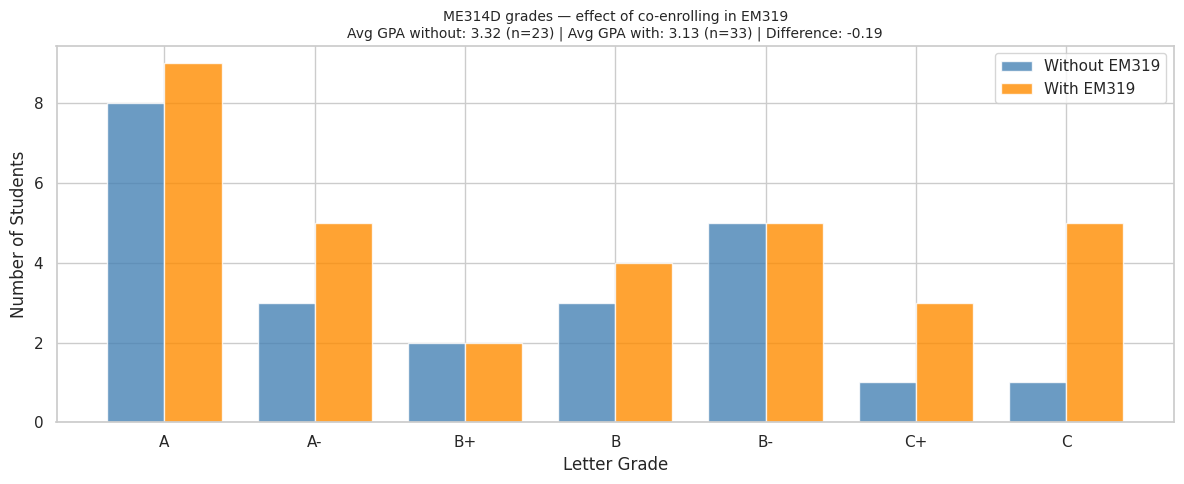

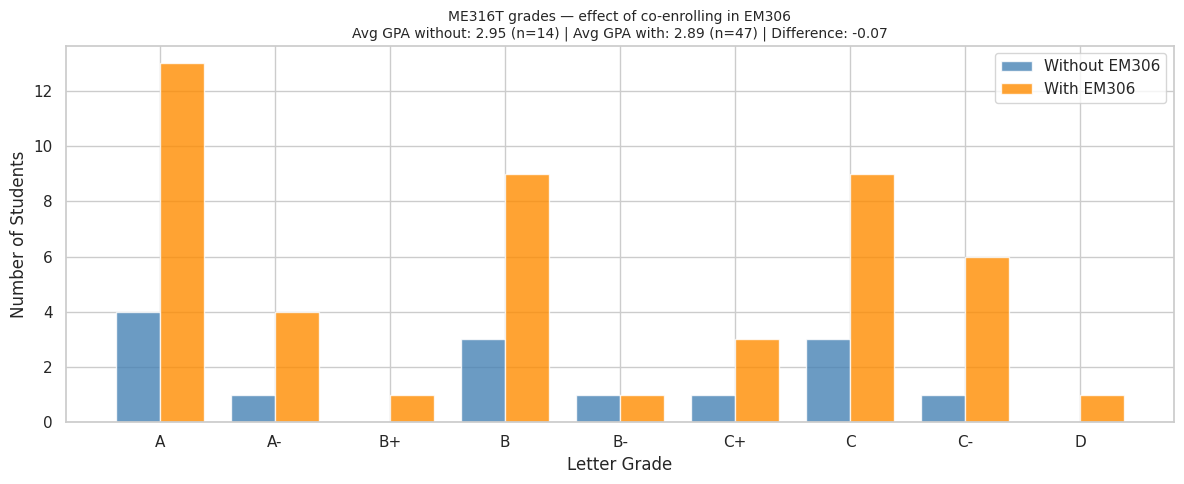

In [ ]:
# ── Step 3: visualize — does a co-enrolled course change your grade? ───────────
# For a given TARGET course, we compare:
#   Group 1 (blue): students who took TARGET alone (without COMPANION)
#   Group 2 (orange): students who took TARGET alongside COMPANION
# We display side-by-side grade distributions as grouped bars.

def plot_co_enrollment_effect(target_course, companion_course):
    """
    Compares grade distributions in `target_course` for students who
    did vs did not simultaneously take `companion_course`.

    Parameters
    ----------
    target_course : str   e.g. 'M408C'
    companion_course : str   e.g. 'CH301'
    """
    GRADE_ORDER = ['A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F']

    # Identify which student-semesters included the companion course
    # (we use a set for O(1) lookup)
    with_companion = set()
    for _, row in co_enrollment.iterrows():
        if (target_course in row['courses_taken_together'] and
                companion_course in row['courses_taken_together']):
            with_companion.add((row['student_id'], row['year'], row['semester']))

    # Build a boolean flag on the target-course rows
    target_df = df[df['course_number'] == target_course].dropna(subset=['letter_grade']).copy()
    target_df['took_companion'] = target_df.apply(
        lambda r: (r['student_id'], r['year'], r['semester']) in with_companion, axis=1
    )

    if target_df.empty:
        print(f'No letter grade data for {target_course}.')
        return

    # Count grades in each group, restricted to grades that appeared at all
    yes = target_df[target_df['took_companion']]['letter_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)
    no  = target_df[~target_df['took_companion']]['letter_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)

    # Only keep columns where at least one group had a non-zero count
    present = [g for g in GRADE_ORDER if yes[g] > 0 or no[g] > 0]
    yes = yes[present]
    no  = no[present]

    # --- Plot side-by-side grouped bars ---
    x     = np.arange(len(present))
    width = 0.38
    fig, ax = plt.subplots(figsize=(12, 5))

    bars_no  = ax.bar(x - width/2, no.values,  width, label=f'Without {companion_course}', color='steelblue',  alpha=0.8)
    bars_yes = ax.bar(x + width/2, yes.values, width, label=f'With {companion_course}',    color='darkorange', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(present)
    ax.set_xlabel('Letter Grade')
    ax.set_ylabel('Number of Students')

    # Compute and print the GPA difference between groups
    gpa_yes = target_df[target_df['took_companion']]['grade_points'].mean()
    gpa_no  = target_df[~target_df['took_companion']]['grade_points'].mean()
    diff    = gpa_yes - gpa_no if not np.isnan(gpa_yes) else None

    n_yes = yes.sum()
    n_no  = no.sum()
    diff_str = f'{diff:+.2f}' if diff is not None else 'N/A'

    ax.set_title(
        f'{target_course} grades — effect of co-enrolling in {companion_course}\n'
        f'Avg GPA without: {gpa_no:.2f} (n={n_no}) | '
        f'Avg GPA with: {gpa_yes:.2f} (n={n_yes}) | '
        f'Difference: {diff_str}',
        fontsize=10
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


# ── Demo: use the most common pairs from the pair_df table above ────────────
# Try any pair you're curious about.

plot_co_enrollment_effect('ME314D', 'EM319')
plot_co_enrollment_effect('ME316T', 'EM306')

### 1C — Department-level GPA heatmap

Instead of looking at one course at a time, we zoom out:
what is the average GPA per department, broken down by semester?

A heatmap lets you spot at a glance which departments are hardest
(dark cells = low GPA) and whether difficulty changes by semester.

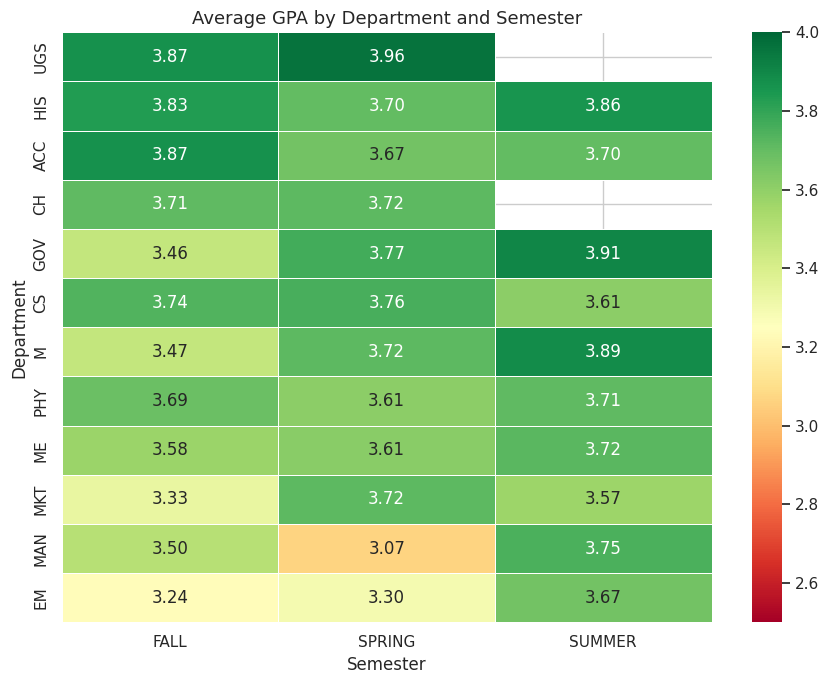

Departments ordered hardest → easiest (by overall avg GPA):
department
EM     3.28
MAN    3.49
MKT    3.51
M      3.59
ME     3.59
PHY    3.65
GOV    3.67
CH     3.71
CS     3.72
ACC    3.72
HIS    3.80
UGS    3.91


In [ ]:
# ── Build a pivot: rows = department, columns = semester ──────────────────────
# We only keep the top 12 departments by total graded records so the heatmap
# is readable. Departments with only 1-2 records produce unreliable averages.

# Count how many graded rows each department has
dept_counts = (
    df.dropna(subset=['grade_points'])
    .groupby('department')['grade_points']
    .count()
    .sort_values(ascending=False)
)
top_depts = dept_counts.head(12).index.tolist()

# Compute mean GPA per (department, semester) combination
# pivot_table reshapes this into a 2D grid suitable for a heatmap
heatmap_data = (
    df[df['department'].isin(top_depts)]
    .dropna(subset=['grade_points'])
    .groupby(['department', 'semester'])['grade_points']
    .mean()
    .reset_index()
    .pivot(index='department', columns='semester', values='grade_points')
)

# Sort departments so highest overall GPA is at the top
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values(ascending=False).index
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    heatmap_data,
    annot=True,          # show the numeric GPA value in each cell
    fmt='.2f',           # format numbers to 2 decimal places
    cmap='RdYlGn',       # red = low GPA, green = high GPA
    vmin=2.5, vmax=4.0,  # fix the color scale across all cells
    linewidths=0.5,
    ax=ax
)
ax.set_title('Average GPA by Department and Semester', fontsize=13)
ax.set_xlabel('Semester')
ax.set_ylabel('Department')
plt.tight_layout()
plt.show()

print('Departments ordered hardest → easiest (by overall avg GPA):')
overall_dept_gpa = (
    df[df['department'].isin(top_depts)]
    .dropna(subset=['grade_points'])
    .groupby('department')['grade_points']
    .mean()
    .sort_values()
)
print(overall_dept_gpa.round(2).to_string())

### 1D — GPA distribution by credits (3-credit vs 4-credit)

A simple hypothesis: 4-credit courses are harder (more lab hours, more material).
We test it by overlaying the GPA distributions for 3-credit and 4-credit classes.

---
## Section 2 — Similar Course Finder (NLP)

**Goal:** Given a course you already took or are interested in, find other courses
with the most similar *content* based on their catalog descriptions.

**How it works — TF-IDF cosine similarity:**
1. **TF-IDF** (Term Frequency × Inverse Document Frequency) converts each course
   description into a vector of numbers. Words that appear a lot in one description
   but rarely across all descriptions get high scores — they're distinctive.
2. **Cosine similarity** measures the angle between two vectors. An angle of 0°
   means identical (score = 1.0); 90° means completely unrelated (score = 0.0).

No model training is needed — this is pure math on text.

In [ ]:
# ── Step 1: build the TF-IDF matrix ──────────────────────────────────────────
# We want exactly ONE description per course number.
# First, drop rows where course_description is missing.
# Then take the FIRST description we see for each course (they're usually identical).

course_desc_df = (
    df.dropna(subset=['course_description'])
    .groupby('course_number')['course_description']
    .first()
    .reset_index()
)

print(f'Courses with descriptions: {len(course_desc_df)}')

# TfidfVectorizer does three things automatically:
#   1. Tokenizes each description into words
#   2. Removes common English words ('the', 'and', 'of' ...) via stop_words
#   3. Computes TF-IDF weights and returns a sparse matrix
# min_df=2 ignores words that appear in fewer than 2 courses (very rare/typo words)
vectorizer = TfidfVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))
# ngram_range=(1,2) means single words AND two-word phrases are both considered.
# 'machine learning' as a bigram is more meaningful than 'machine' + 'learning' alone.

tfidf_matrix = vectorizer.fit_transform(course_desc_df['course_description'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}  '
      f'({tfidf_matrix.shape[0]} courses × {tfidf_matrix.shape[1]} features)')

Courses with descriptions: 253
TF-IDF matrix shape: (253, 1350)  (253 courses × 1350 features)


In [ ]:
# ── Step 2: compute all pairwise cosine similarities ─────────────────────────
# cosine_similarity returns an n×n matrix where entry [i, j] is the similarity
# score between course i and course j (1.0 = identical, 0.0 = unrelated).
# The diagonal is always 1.0 (a course is identical to itself).

similarity_matrix = cosine_similarity(tfidf_matrix)
course_index = course_desc_df['course_number'].tolist()  # maps row/col index → course name

print('Similarity matrix computed.')
print(f'Shape: {similarity_matrix.shape}  (courses × courses)')

Similarity matrix computed.
Shape: (253, 253)  (courses × courses)


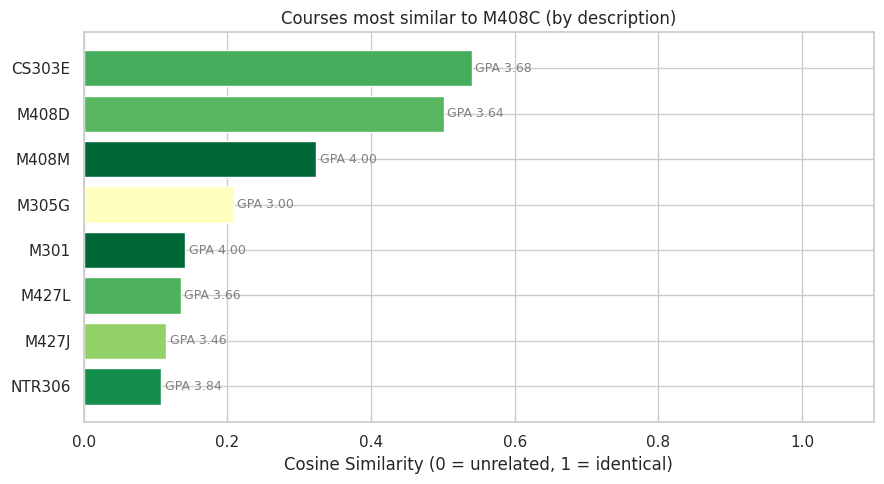


Top 8 courses similar to M408C:
course  similarity_score  avg_gpa                                                                                                                 description
CS303E             0.540     3.68 Problem solving and fundamental algorithms for various applications in science, business, and on the World Wide Web, and...
 M408D             0.501     3.64 Certain sections of this course are designated as advanced placement or honors sections; they are restricted to students...
 M408M             0.324     4.00                                                                                                   MULTIVARIABLE CALCULUS...
 M305G             0.209     3.00                                                                                             PREPARATION FOR CALCULUS-CNS...
  M301             0.141     4.00 Subjects include a brief review of elementary algebra; linear, quadratic, exponential, and logarithmic functions; polyno...
 M427L             

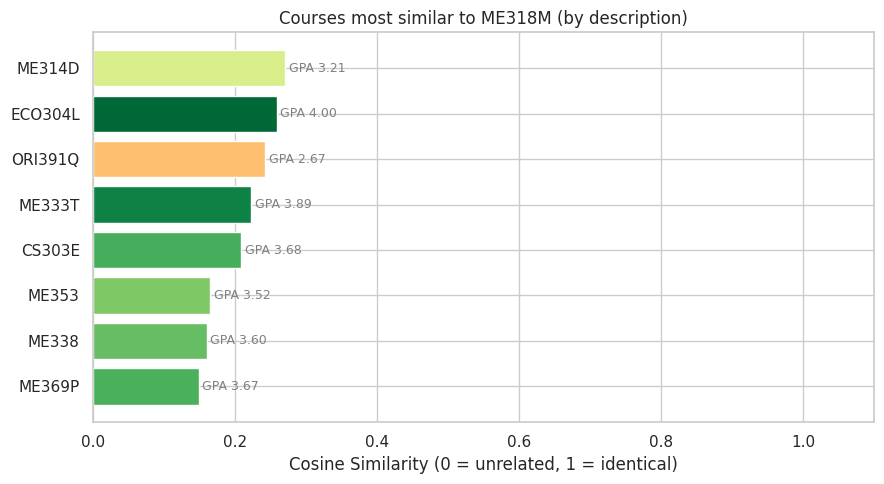


Top 8 courses similar to ME318M:
 course  similarity_score  avg_gpa                                                                                                                 description
 ME314D             0.271     3.21                                                Analysis of motions, forces, momenta, and energies in mechanical systems....
ECO304L             0.259     4.00 Analysis of the economy as a whole. Measurement of output, the price level, and employment. Basic theories of the determ...
ORI391Q             0.243     2.67 Mathematical optimization techniques with applications to engineering and industrial problems. Models, algorithms, and t...
 ME333T             0.223     3.89 Professional communication skills for engineers, with emphasis on research, writing, and oral presentation on topics of ...
 CS303E             0.209     3.68 Problem solving and fundamental algorithms for various applications in science, business, and on the World Wide Web, and...
  ME353     

In [ ]:
# ── Step 3: define a function to look up similar courses ──────────────────────

def find_similar_courses(course_number, top_n=5):
    """
    Returns the `top_n` most similar courses to `course_number` based on
    TF-IDF cosine similarity of their catalog descriptions.

    Parameters
    ----------
    course_number : str   e.g. 'M408C'
    top_n : int           how many similar courses to return (default 5)

    Returns
    -------
    DataFrame with columns: course, similarity_score, avg_gpa, description
    """
    if course_number not in course_index:
        print(f'{course_number} not found in the description index.')
        return None

    # Find this course's row in the similarity matrix
    idx = course_index.index(course_number)

    # Get all similarity scores for this course, sorted descending.
    # We skip index 0 because that is the course itself (score = 1.0).
    scores = list(enumerate(similarity_matrix[idx]))
    scores.sort(key=lambda x: x[1], reverse=True)
    top_courses = scores[1:top_n + 1]   # skip index 0 (self)

    # Build a result table
    results = []
    for i, score in top_courses:
        c = course_index[i]
        avg_gpa = df[df['course_number'] == c]['grade_points'].mean()
        desc    = course_desc_df.loc[course_desc_df['course_number'] == c,
                                     'course_description'].values[0]
        results.append({'course': c, 'similarity_score': round(score, 3),
                        'avg_gpa': round(avg_gpa, 2) if not np.isnan(avg_gpa) else None,
                        'description': desc[:120] + '...'})

    return pd.DataFrame(results)


# ── Step 4: visualize similar courses as a horizontal bar chart ───────────────

def plot_similar_courses(course_number, top_n=8):
    """
    Calls find_similar_courses and plots a horizontal bar chart of
    similarity scores, with avg GPA annotated on each bar.
    """
    result = find_similar_courses(course_number, top_n=top_n)
    if result is None:
        return

    fig, ax = plt.subplots(figsize=(9, 5))

    # Color each bar by avg GPA: green = high, red = low
    gpa_vals = result['avg_gpa'].fillna(2.5).values
    norm     = plt.Normalize(vmin=2.0, vmax=4.0)
    colors   = plt.cm.RdYlGn(norm(gpa_vals))

    bars = ax.barh(result['course'], result['similarity_score'],
                   color=colors, edgecolor='white')

    # Annotate each bar with the avg GPA so the reader can assess both dimensions
    for bar, gpa in zip(bars, result['avg_gpa']):
        gpa_txt = f'GPA {gpa:.2f}' if pd.notna(gpa) else 'GPA N/A'
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                gpa_txt, va='center', fontsize=9, color='gray')

    ax.set_xlabel('Cosine Similarity (0 = unrelated, 1 = identical)')
    ax.set_title(f'Courses most similar to {course_number} (by description)')
    ax.set_xlim(0, 1.1)
    ax.invert_yaxis()   # highest similarity at the top
    plt.tight_layout()
    plt.show()

    print(f'\nTop {top_n} courses similar to {course_number}:')
    print(result[['course', 'similarity_score', 'avg_gpa', 'description']].to_string(index=False))


# ── Demo ─────────────────────────────────────────────────────────────────────
plot_similar_courses('M408C')
plot_similar_courses('ME318M')


---
## Section 3 — Next-Course Recommender with Grade Prediction

**Goal:** Given what courses a student has already taken (and how well they did),
recommend what courses to take next and predict what grade they'd likely earn.

**Approach — collaborative filtering + GPA-weighted scoring:**
1. Find students in the dataset who took a similar set of courses to the target student.
2. Look at what those similar students took *next* (after the courses the target already finished).
3. Weight each candidate course by: (a) how often similar students took it, and (b)
   the average grade those similar students earned — because a course everyone failed
   is less worth recommending.
4. Predict the target student's expected grade using those similar students' grades
   in that course, weighted by how similar each student is.

This is similar in spirit to how Netflix recommends movies:
*people who liked what you liked also liked these.*

In [ ]:
# ── Step 1: build a student-course GPA matrix ─────────────────────────────────
# Each row is a student, each column is a course.
# The value is the GPA points that student earned (NaN if they never took it).
# We use this matrix to measure how similar two students are.

# Only keep rows with a real letter grade
graded_df = df.dropna(subset=['grade_points'])

# pivot_table automatically averages if a student took the same course twice
student_course_matrix = graded_df.pivot_table(
    index='student_id',
    columns='course_number',
    values='grade_points',
    aggfunc='mean'
)

print(f'Student-course matrix: {student_course_matrix.shape}  '
      f'({student_course_matrix.shape[0]} students × {student_course_matrix.shape[1]} courses)')
print(f'Sparsity: {student_course_matrix.isna().mean().mean():.1%} of cells are NaN')

Student-course matrix: (71, 224)  (71 students × 224 courses)
Sparsity: 85.7% of cells are NaN


In [ ]:
# ── Step 2: define the recommender function ───────────────────────────────────

def recommend_next_courses(student_id, already_taken=None, top_n=5, min_similarity=0.1):
    """
    Recommends the next courses for a student and predicts expected grade.

    Parameters
    ----------
    student_id : int/str
        Must exist in the dataset.
    already_taken : list of str, optional
        Override the courses the student already took.
        If None, use every course in the dataset for this student.
    top_n : int
        Number of recommendations to return.
    min_similarity : float
        Minimum cosine similarity for a neighbor to be considered.

    Returns
    -------
    DataFrame with recommended courses and predicted GPA.
    """

    # --- Find which courses the student already completed ---
    if already_taken is None:
        already_taken = set(
            graded_df[graded_df['student_id'] == student_id]['course_number']
        )
    else:
        already_taken = set(already_taken)

    # --- Get this student's row from the matrix ---
    if student_id not in student_course_matrix.index:
        print(f'Student {student_id} not in matrix.')
        return None

    student_vector = student_course_matrix.loc[[student_id]]  # shape (1, n_courses)

    # Fill NaN with 0 for the similarity calculation.
    # A student who never took a course contributes 0 overlap with another student
    # who did take it — that is the right semantic for cosine similarity here.
    student_filled = student_vector.fillna(0)
    all_filled     = student_course_matrix.fillna(0)

    # --- Compute similarity between this student and every other student ---
    # cosine_similarity returns shape (1, n_students)
    sims = cosine_similarity(student_filled, all_filled)[0]

    # Build a mapping: other_student_id → similarity_score
    # Skip the student themselves (sim = 1.0 trivially)
    sim_map = {
        sid: sim
        for sid, sim in zip(student_course_matrix.index, sims)
        if sid != student_id and sim >= min_similarity
    }

    if not sim_map:
        print('No sufficiently similar students found. Try lowering min_similarity.')
        return None

    # --- Collect candidate courses from similar students ---
    # For each neighbor student, look at courses they took that our student hasn't.
    # Record (course, neighbor's grade, similarity weight) for each observation.
    candidate_scores = defaultdict(list)   # course → [(grade, similarity), ...]

    for neighbor_id, sim in sim_map.items():
        neighbor_rows = graded_df[
            (graded_df['student_id'] == neighbor_id) &
            (~graded_df['course_number'].isin(already_taken))
        ]
        for _, row in neighbor_rows.iterrows():
            candidate_scores[row['course_number']].append((row['grade_points'], sim))

    if not candidate_scores:
        print('No candidate courses found for this student.')
        return None

    # --- Score each candidate course ---
    # predicted_gpa: weighted average of neighbors' grades, weighted by similarity.
    #   A neighbor who is more similar to our student gets more weight.
    # confidence: how many distinct similar students took this course.
    #   Higher = more reliable prediction.
    recommendations = []
    for course, observations in candidate_scores.items():
        grades   = np.array([g for g, _ in observations])
        weights  = np.array([s for _, s in observations])
        # numpy.average with weights: sum(grade * weight) / sum(weights)
        pred_gpa = np.average(grades, weights=weights)
        n_neighbors = len(set(observations))  # rough count of contributing neighbors
        recommendations.append({
            'recommended_course': course,
            'predicted_gpa':      round(pred_gpa, 2),
            'num_similar_students_who_took_it': len(observations),
        })

    result = (
        pd.DataFrame(recommendations)
        .sort_values(['num_similar_students_who_took_it', 'predicted_gpa'],
                     ascending=[False, False])
        .head(top_n)
        .reset_index(drop=True)
    )

    # Add the course description as a convenience column
    result['description'] = result['recommended_course'].map(
        course_desc_df.set_index('course_number')['course_description']
    ).str[:100]

    return result


print('Recommender function defined.')

Recommender function defined.


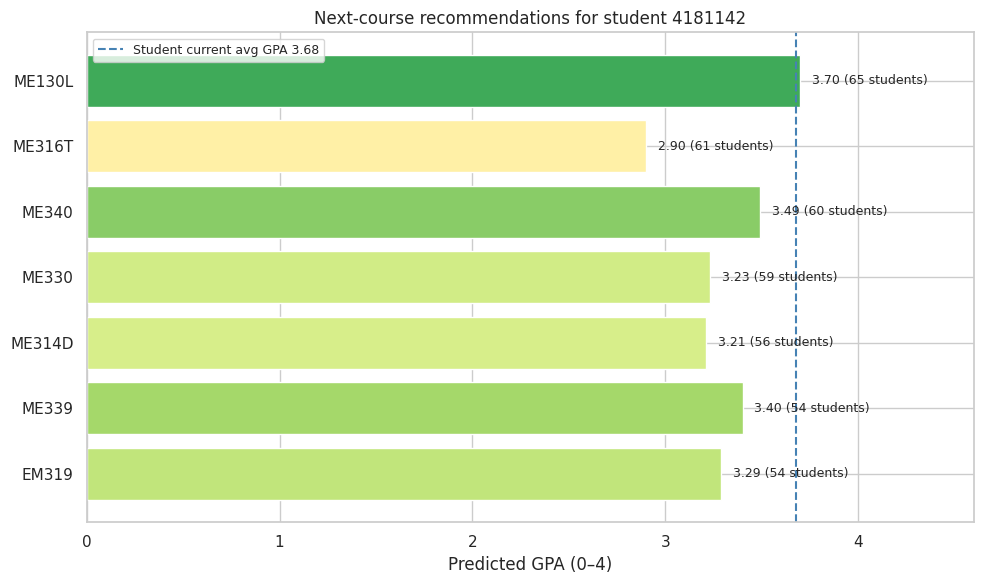


Full recommendation table for student 4181142:
recommended_course  predicted_gpa  num_similar_students_who_took_it                                                                                          description
            ME130L           3.70                                65 Experimental design concepts, uncertainty analysis, and systems analysis as applied to thermodynamic
            ME316T           2.90                                61 Properties, heat and work, first and second laws, thermodynamic processes, introduction to ideal pow
             ME340           3.49                                60 Theory and application of electrical circuits, electronics, and electromechanical devices; concepts 
             ME330           3.23                                59 Fluid properties, statics, conservation laws, inviscid and viscous incompressible flow, flow in conf
            ME314D           3.21                                56                            Analysis of 

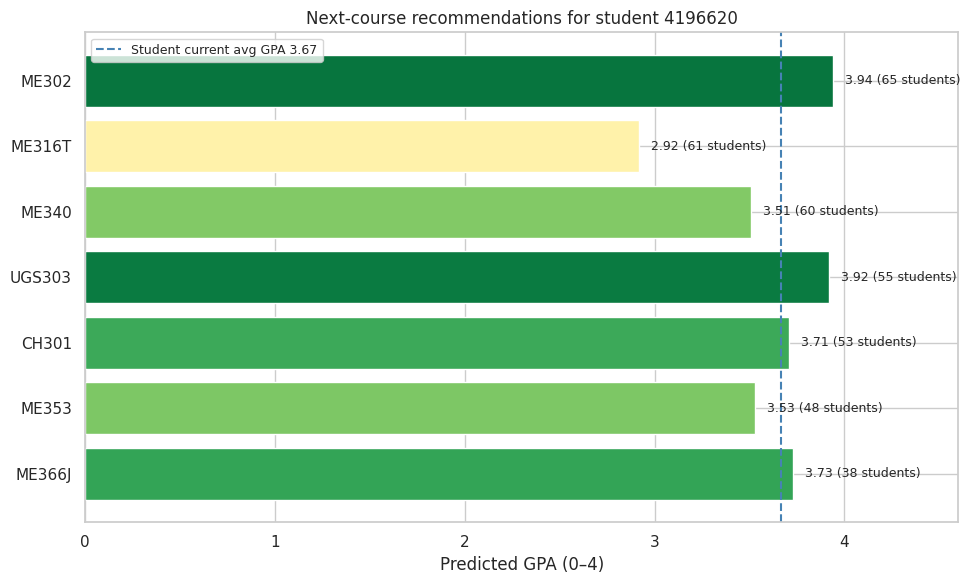


Full recommendation table for student 4196620:
recommended_course  predicted_gpa  num_similar_students_who_took_it                                                                                          description
             ME302           3.94                                65 Introduction to mechanical engineering education and practice through lectures and laboratory experi
            ME316T           2.92                                61 Properties, heat and work, first and second laws, thermodynamic processes, introduction to ideal pow
             ME340           3.51                                60 Theory and application of electrical circuits, electronics, and electromechanical devices; concepts 
            UGS303           3.92                                55 Large-group lecture and discussion class focusing on a contemporary issue. Designed to introduce und
             CH301           3.71                                53                                        

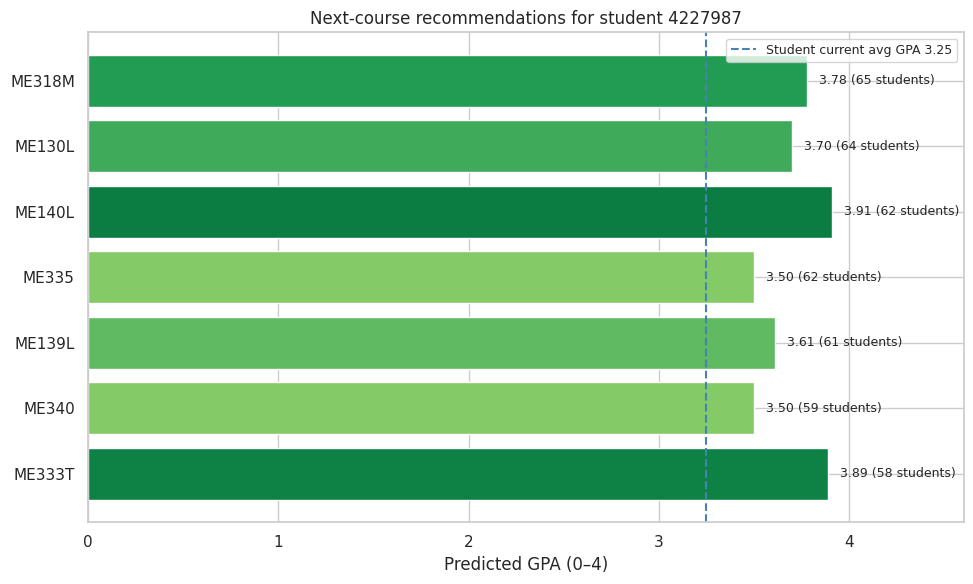


Full recommendation table for student 4227987:
recommended_course  predicted_gpa  num_similar_students_who_took_it                                                                                          description
            ME318M           3.78                                65 An investigation of applied numerical analysis, programming of computational algorithms using mathem
            ME130L           3.70                                64 Experimental design concepts, uncertainty analysis, and systems analysis as applied to thermodynamic
            ME140L           3.91                                62 Hands-on laboratory using hand-held and bench-top electronic test and prototyping equipment for circ
             ME335           3.50                                62 Fundamentals of probability, distribution theory, data analysis and statistics, interval estimation,
            ME139L           3.61                                61 Experimental design concepts, uncertain

In [ ]:
# ── Step 3: visualize recommendations ────────────────────────────────────────

def plot_recommendations(student_id, already_taken=None, top_n=8):
    """
    Calls recommend_next_courses and plots the results.
    Bars are colored by predicted GPA (red = predicted low, green = high).
    Bar width represents predicted GPA; annotations show supporting student count.
    """
    recs = recommend_next_courses(student_id, already_taken=already_taken, top_n=top_n)
    if recs is None:
        return

    # Color scale: predicted GPA mapped to a red-yellow-green palette
    norm   = plt.Normalize(vmin=2.0, vmax=4.0)
    colors = plt.cm.RdYlGn(norm(recs['predicted_gpa'].values))

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        recs['recommended_course'],
        recs['predicted_gpa'],
        color=colors,
        edgecolor='white'
    )

    # Add a vertical line at the student's current overall average GPA
    student_gpa = graded_df[graded_df['student_id'] == student_id]['grade_points'].mean()
    if not np.isnan(student_gpa):
        ax.axvline(student_gpa, color='steelblue', linestyle='--', linewidth=1.5,
                   label=f'Student current avg GPA {student_gpa:.2f}')
        ax.legend(fontsize=9)

    # Annotate each bar: predicted GPA + how many similar students support the estimate
    for bar, (_, row) in zip(bars, recs.iterrows()):
        label = f'  {row["predicted_gpa"]:.2f} ({row["num_similar_students_who_took_it"]} students)'
        ax.text(bar.get_width() + 0.02,
                bar.get_y() + bar.get_height() / 2,
                label, va='center', fontsize=9)

    ax.set_xlabel('Predicted GPA (0–4)')
    ax.set_xlim(0, 4.6)
    ax.set_title(f'Next-course recommendations for student {student_id}', fontsize=12)
    ax.invert_yaxis()  # most recommended at the top
    plt.tight_layout()
    plt.show()

    print(f'\nFull recommendation table for student {student_id}:')
    print(recs.to_string(index=False))


# ── Demo: recommend courses for the first few students in the data ────────────
# Replace the student_id with any ID from your dataset.
sample_students = df['student_id'].unique()[:3]
for sid in sample_students:
    plot_recommendations(sid, top_n=7)

### 3B — Simulate a new student (hypothetical course history)

You can also run the recommender for a *hypothetical* student — someone who isn't
in the dataset — by passing a custom `already_taken` list and temporarily inserting
a fake student row into the matrix.

This is useful for your demo: you can say
*"If a student has taken M408C, CS303E, and PHY303K, what should they take next?"*

In [ ]:
# ── Hypothetical student recommender ─────────────────────────────────────────
# We create a fake row in the matrix, compute similarities, then remove the row.

def recommend_for_hypothetical_student(courses_taken_with_grades, top_n=7):
    """
    Recommends next courses for a student not in the dataset.

    Parameters
    ----------
    courses_taken_with_grades : dict
        {course_number: gpa_points}  e.g. {'M408C': 3.67, 'CS303E': 4.0}
    top_n : int
        Number of recommendations.
    """
    FAKE_ID = '__hypothetical__'

    # Insert the fake student into a copy of the matrix
    global student_course_matrix
    new_row = pd.Series(courses_taken_with_grades, name=FAKE_ID)
    augmented = pd.concat([student_course_matrix, new_row.to_frame().T])

    # Temporarily replace the global so recommend_next_courses can find it
    original_matrix = student_course_matrix
    student_course_matrix = augmented

    result = recommend_next_courses(
        student_id=FAKE_ID,
        already_taken=list(courses_taken_with_grades.keys()),
        top_n=top_n
    )

    # Restore the original
    student_course_matrix = original_matrix

    if result is not None:
        print('Recommendations for hypothetical student:')
        print(result.to_string(index=False))

    return result


# ── Example: a student who aced calc, did okay in chem, loves CS ──────────────
# Keys are course numbers, values are GPA points (4.0 = A, 3.0 = B, etc.)
hypothetical = {
    'M408C':  4.00,   # Differential Calculus — A
    'CS303E': 4.00,   # Intro CS (Python) — A
    'CH301':  3.00,   # Chemistry I — B
    'M408D':  3.67,   # Integral Calculus — A-
}

recs = recommend_for_hypothetical_student(hypothetical, top_n=8)

Recommendations for hypothetical student:
recommended_course  predicted_gpa  num_similar_students_who_took_it                                                                                          description
             ME302           3.94                                58 Introduction to mechanical engineering education and practice through lectures and laboratory experi
            ME318M           3.79                                58 An investigation of applied numerical analysis, programming of computational algorithms using mathem
             ME334           3.53                                58 Fundamental aspects of the structure, properties, and behavior of engineering materials. Three lectu
             M427J           3.41                                58 Ordinary differential equations, introduction to vector spaces, linear operators and eigenvalues, sy
             EM306           3.32                                58 Vector algebra, force systems, free-body diag

---
## Section 4 — Interest-Based Course Bundling

**Goal:** Show which courses are historically taken *together* in semester bundles,
and then let a student say "I'm interested in X" and get a full recommended
semester schedule.

**How it works:**
- We already built `pair_df` (pairs of courses taken together) in Section 1B.
- Here we extend that idea: given a seed course or interest keyword, find
  the top co-enrollment companions and present them as a suggested schedule.

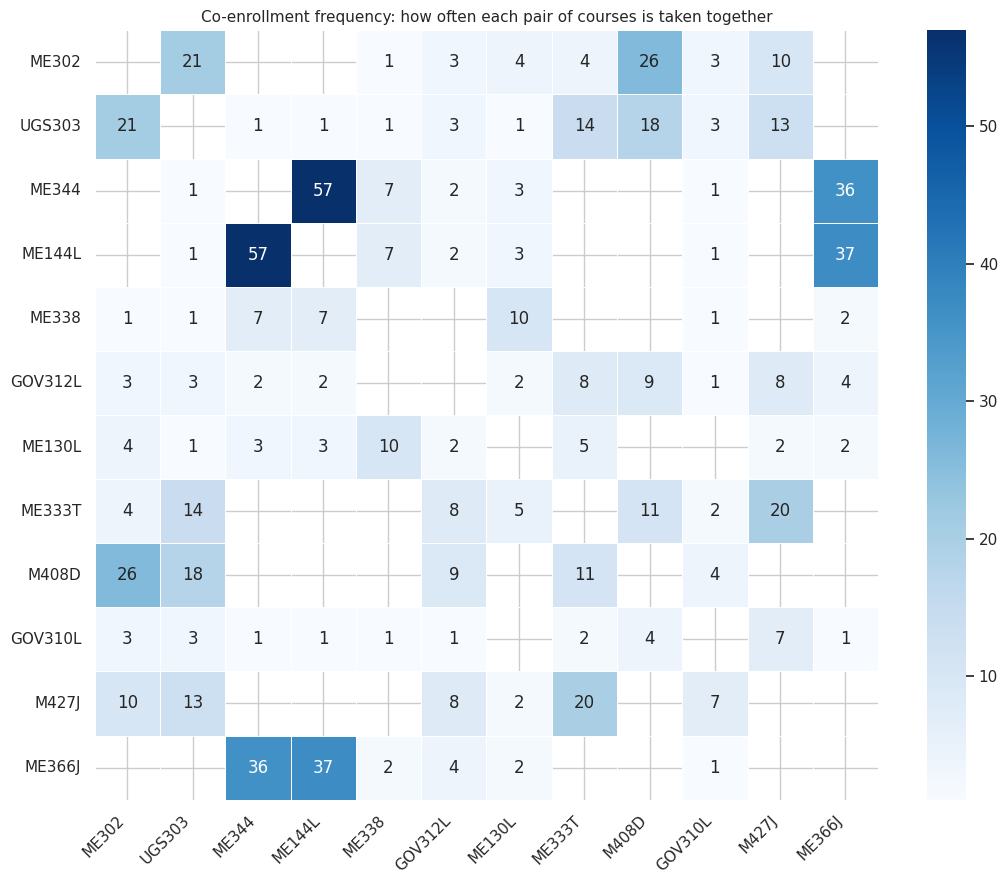

In [ ]:
# ── Co-enrollment heatmap: which courses appear together most often? ───────────
# We visualize the top 12 courses by total co-enrollment count.
# The cell value is the number of students who took BOTH courses in the same semester.

# Identify the top 12 courses by total pairwise appearances
top_pair_courses = (
    pd.concat([pair_df['course_a'], pair_df['course_b']])
    .value_counts()
    .head(12)
    .index.tolist()
)

# Build an n×n co-occurrence matrix for these top courses
co_matrix = pd.DataFrame(0, index=top_pair_courses, columns=top_pair_courses)

for _, row in pair_df.iterrows():
    a, b, cnt = row['course_a'], row['course_b'], row['co_enrollment_count']
    if a in top_pair_courses and b in top_pair_courses:
        co_matrix.loc[a, b] = cnt
        co_matrix.loc[b, a] = cnt   # symmetric: if A+B, also B+A

# Plot as a heatmap
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    mask=(co_matrix == 0)   # leave zeros as white (no co-enrollment)
)
ax.set_title('Co-enrollment frequency: how often each pair of courses is taken together',
             fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


===== Suggested semester bundle (seed: M427J) =====
Total credits: 16
 course  credits  avg_gpa  students_took_with_seed                                                                                   description
  M427J        4     3.46                        0 Ordinary differential equations, introduction to vector spaces, linear operators and eigen...
  EM306        3     3.28                       39 Vector algebra, force systems, free-body diagrams; engineering applications of equilibrium...
 ME316T        3     2.90                       38 Properties, heat and work, first and second laws, thermodynamic processes, introduction to...
 ME333T        3     3.89                       20 Professional communication skills for engineers, with emphasis on research, writing, and o...
PHY303K        3     3.56                       13           A general survey of physics; primarily laws of motion, heat, and wave phenomena....


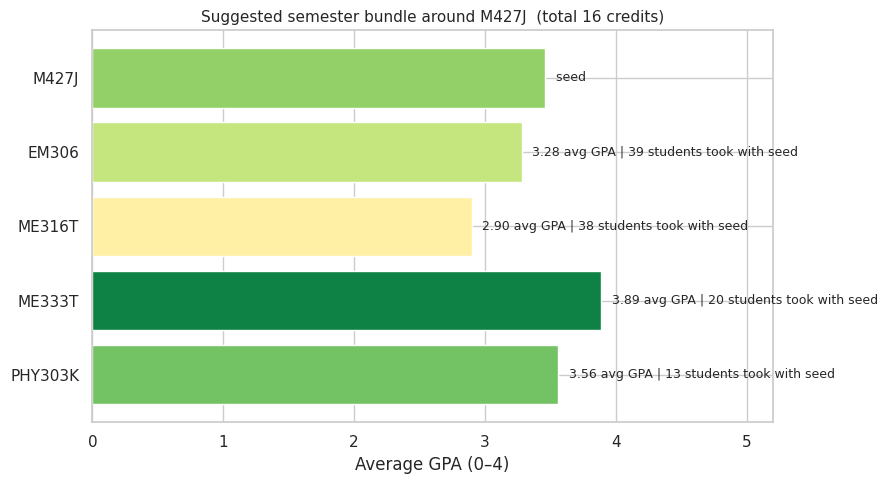


===== Suggested semester bundle (seed: CS303E) =====
Total credits: 17
course  credits  avg_gpa  students_took_with_seed                                                                                   description
CS303E        3     3.68                        0 Problem solving and fundamental algorithms for various applications in science, business, ...
 EM306        3     3.28                        8 Vector algebra, force systems, free-body diagrams; engineering applications of equilibrium...
 M427J        4     3.46                        6 Ordinary differential equations, introduction to vector spaces, linear operators and eigen...
ME316T        3     2.90                        6 Properties, heat and work, first and second laws, thermodynamic processes, introduction to...
 M427L        4     3.66                        6 Matrices, elements of vector analysis and calculus of functions of several variables, incl...


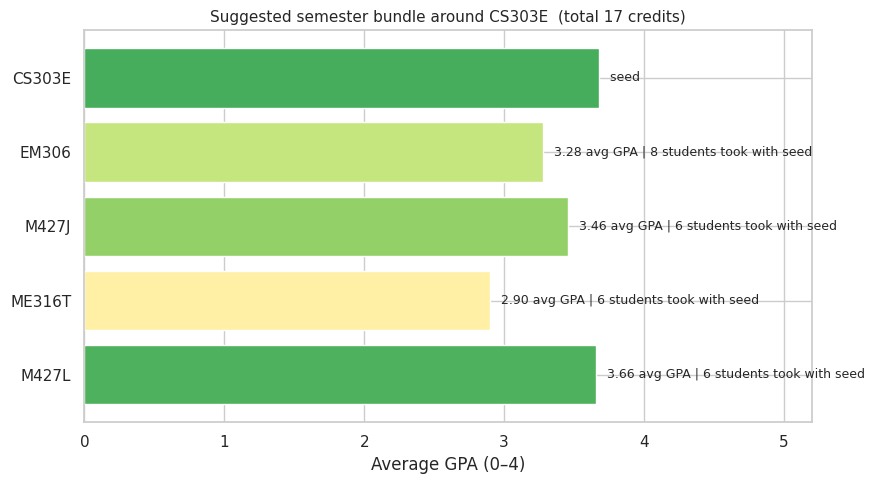

In [ ]:
# ── Suggested semester bundle for a seed course ───────────────────────────────
# Given a course a student wants to take, find the courses most commonly
# taken alongside it and present a suggested full semester schedule.

def suggest_semester_bundle(seed_course, bundle_size=4):
    """
    Suggests a full semester course bundle built around `seed_course`.

    The seed course is the one the student knows they want to take.
    We find the `bundle_size - 1` courses most commonly taken with it.

    Parameters
    ----------
    seed_course : str   e.g. 'M427J'
    bundle_size : int   total number of courses in the suggested bundle
    """
    # Filter the pair table to rows involving the seed course
    companions = pair_df[
        (pair_df['course_a'] == seed_course) | (pair_df['course_b'] == seed_course)
    ].copy()

    if companions.empty:
        print(f'No co-enrollment data for {seed_course}.')
        return

    # Normalize: always put the seed in course_a so course_b is the companion
    companions['companion'] = companions.apply(
        lambda r: r['course_b'] if r['course_a'] == seed_course else r['course_a'],
        axis=1
    )

    top_companions = (
        companions
        .nlargest(bundle_size - 1, 'co_enrollment_count')
        [['companion', 'co_enrollment_count']]
        .reset_index(drop=True)
    )

    # Build the final bundle: seed + top companions
    bundle = [seed_course] + top_companions['companion'].tolist()

    # Look up avg GPA and description for each course in the bundle
    bundle_data = []
    for c in bundle:
        gpa  = df[df['course_number'] == c]['grade_points'].mean()
        desc = course_desc_df.loc[course_desc_df['course_number'] == c,
                                   'course_description']
        desc = desc.values[0][:90] + '...' if len(desc) > 0 else 'No description'
        credits = df[df['course_number'] == c]['credits'].mode()
        credits = credits.values[0] if len(credits) > 0 else '?'
        co_cnt = (
            0 if c == seed_course else
            int(top_companions[top_companions['companion'] == c]['co_enrollment_count'].values[0])
        )
        bundle_data.append({
            'course': c,
            'credits': credits,
            'avg_gpa': round(gpa, 2) if not np.isnan(gpa) else None,
            'students_took_with_seed': co_cnt,
            'description': desc
        })

    bundle_df = pd.DataFrame(bundle_data)
    total_credits = bundle_df['credits'].sum()

    print(f'\n===== Suggested semester bundle (seed: {seed_course}) =====')
    print(f'Total credits: {total_credits}')
    print(bundle_df.to_string(index=False))

    # --- Plot: horizontal bars with avg GPA, annotated with co-enrollment count ---
    norm   = plt.Normalize(vmin=2.0, vmax=4.0)
    colors = plt.cm.RdYlGn(norm(bundle_df['avg_gpa'].fillna(2.5).values))

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(bundle_df['course'], bundle_df['avg_gpa'],
                   color=colors, edgecolor='white')

    for bar, (_, row) in zip(bars, bundle_df.iterrows()):
        co_label = f'  seed' if row['students_took_with_seed'] == 0 else \
                   f'  {row["avg_gpa"]:.2f} avg GPA | {row["students_took_with_seed"]} students took with seed'
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                co_label, va='center', fontsize=9)

    ax.set_xlabel('Average GPA (0–4)')
    ax.set_xlim(0, 5.2)
    ax.set_title(f'Suggested semester bundle around {seed_course}  '
                 f'(total {total_credits} credits)', fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


# ── Demo ─────────────────────────────────────────────────────────────────────
suggest_semester_bundle('M427J', bundle_size=5)
suggest_semester_bundle('CS303E', bundle_size=5)


===== Semester bundle (anchors: M427J, ME316T, EM306) =====
Total credits (all courses): 16
 course      type  credits  avg_gpa  combined_score anchors_paired                                                                                   description
  M427J    ANCHOR        4     3.46               0              - Ordinary differential equations, introduction to vector spaces, linear operators and eigen...
 ME316T    ANCHOR        3     2.90               0              - Properties, heat and work, first and second laws, thermodynamic processes, introduction to...
  EM306    ANCHOR        3     3.28               0              - Vector algebra, force systems, free-body diagrams; engineering applications of equilibrium...
 ME333T suggested        3     3.89              58              3 Professional communication skills for engineers, with emphasis on research, writing, and o...
PHY303L suggested        3     3.64              43              3                                    

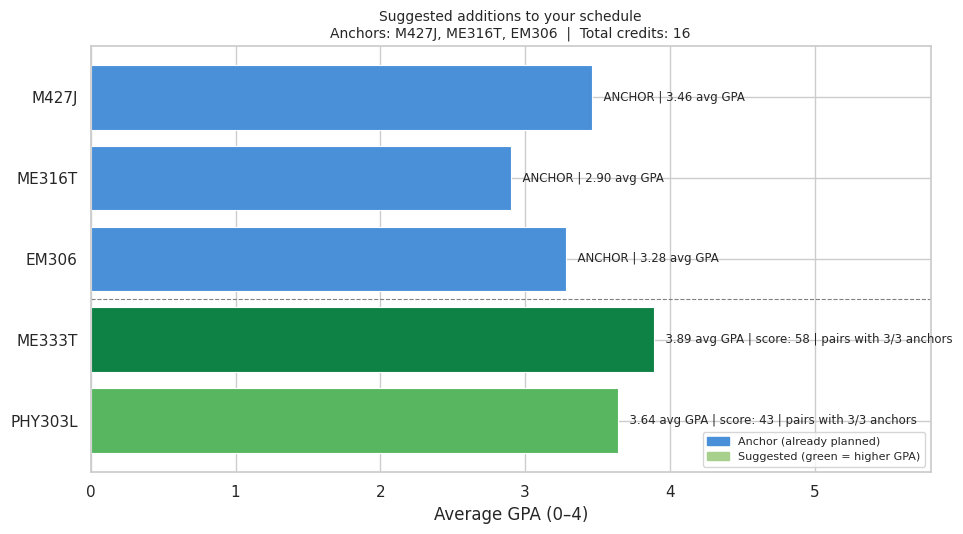


===== Semester bundle (anchors: CS303E, M408D) =====
Total credits (all courses): 17
 course      type  credits  avg_gpa  combined_score anchors_paired                                                                                   description
 CS303E    ANCHOR        3     3.68               0              - Problem solving and fundamental algorithms for various applications in science, business, ...
  M408D    ANCHOR        4     3.64               0              - Certain sections of this course are designated as advanced placement or honors sections; t...
  ME302 suggested        3     3.94              28              2 Introduction to mechanical engineering education and practice through lectures and laborat...
PHY303K suggested        3     3.56              24              1              A general survey of physics; primarily laws of motion, heat, and wave phenomena.
PHY103M suggested        1     3.60              24              1                                           

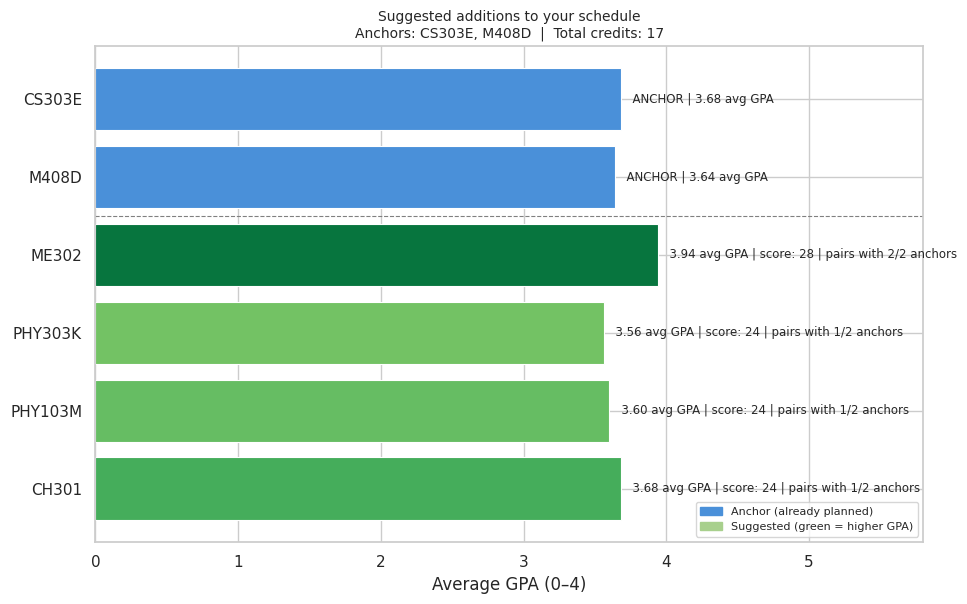

In [ ]:
def suggest_semester_bundle(anchor_courses, n_suggestions=5):
    """
    Given a list of courses a student already plans to take,
    suggest the top N additional courses most commonly taken alongside them.

    Scoring: for each candidate course, sum its co-enrollment count with
    every anchor course. This rewards candidates that pair well with the
    whole schedule, not just one class.

    Parameters
    ----------
    anchor_courses : list[str]   e.g. ['M427J', 'ME316T', 'EM306']
    n_suggestions  : int         how many additional courses to suggest (default 5)
    """
    anchor_set = set(anchor_courses)

    # ── Accumulate co-enrollment scores across all anchor courses ──────────────
    # Think of this like a ranked-choice vote: each anchor casts votes for
    # every course it was historically taken with, weighted by co-enrollment count.
    score = Counter()

    for anchor in anchor_courses:
        companions = pair_df[
            (pair_df['course_a'] == anchor) | (pair_df['course_b'] == anchor)
        ].copy()

        if companions.empty:
            print(f'  Warning: no co-enrollment data for anchor course {anchor}.')
            continue

        companions['companion'] = companions.apply(
            lambda r: r['course_b'] if r['course_a'] == anchor else r['course_a'],
            axis=1
        )

        for _, row in companions.iterrows():
            candidate = row['companion']
            if candidate not in anchor_set:          # never suggest what they already have
                score[candidate] += row['co_enrollment_count']

    if not score:
        print('No suggestions available — check that anchor courses exist in pair_df.')
        return

    # ── Build suggestion list ──────────────────────────────────────────────────
    top_suggestions = pd.DataFrame(
        score.most_common(n_suggestions),
        columns=['course', 'combined_score']
    )

    # ── Assemble full display table: anchors first, then suggestions ───────────
    all_courses = list(anchor_courses) + top_suggestions['course'].tolist()

    rows = []
    for c in all_courses:
        is_anchor = c in anchor_set

        # Avg GPA
        gpa_vals = df[df['course_number'] == c]['grade_points']
        avg_gpa  = round(gpa_vals.mean(), 2) if len(gpa_vals) > 0 and not gpa_vals.isna().all() else None

        # Credits (mode)
        cred_vals = df[df['course_number'] == c]['credits'].mode()
        credits   = int(cred_vals.values[0]) if len(cred_vals) > 0 else '?'

        # Description — fix: check string length, not Series length
        desc_vals = course_desc_df.loc[course_desc_df['course_number'] == c, 'course_description']
        if len(desc_vals) > 0:
            raw = str(desc_vals.values[0])
            desc = (raw[:90] + '...') if len(raw) > 90 else raw
        else:
            desc = 'No description'

        # Combined score (0 for anchors — they're not suggestions)
        combined_score = 0 if is_anchor else int(score[c])

        # How many individual anchors does this candidate pair with?
        anchors_paired = (
            '-' if is_anchor else
            str(sum(1 for a in anchor_courses if score.get(c, 0) > 0
                    and pair_df[
                        ((pair_df['course_a'] == a) & (pair_df['course_b'] == c)) |
                        ((pair_df['course_b'] == a) & (pair_df['course_a'] == c))
                    ].shape[0] > 0))
        )

        rows.append({
            'course':         c,
            'type':           'ANCHOR' if is_anchor else 'suggested',
            'credits':        credits,
            'avg_gpa':        avg_gpa,
            'combined_score': combined_score,
            'anchors_paired': anchors_paired,
            'description':    desc,
        })

    bundle_df = pd.DataFrame(rows)
    total_credits = bundle_df['credits'].replace('?', 0).astype(int).sum()

    # ── Print summary table ────────────────────────────────────────────────────
    anchors_str = ', '.join(anchor_courses)
    print(f'\n===== Semester bundle (anchors: {anchors_str}) =====')
    print(f'Total credits (all courses): {total_credits}')
    print(bundle_df[['course','type','credits','avg_gpa','combined_score','anchors_paired','description']]
          .to_string(index=False))

    # ── Plot ───────────────────────────────────────────────────────────────────
    norm   = plt.Normalize(vmin=2.0, vmax=4.0)
    colors = [
        '#4a90d9' if row['type'] == 'ANCHOR'                        # blue for anchors
        else plt.cm.RdYlGn(norm(row['avg_gpa'] if row['avg_gpa'] else 2.5))  # RdYlGn for suggestions
        for _, row in bundle_df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(10, 0.7 * len(bundle_df) + 2))
    bars = ax.barh(bundle_df['course'], bundle_df['avg_gpa'].fillna(0),
                   color=colors, edgecolor='white', linewidth=0.8)

    # Annotate bars
    for bar, (_, row) in zip(bars, bundle_df.iterrows()):
        if row['type'] == 'ANCHOR':
            label = f"  ANCHOR | {row['avg_gpa']:.2f} avg GPA"
        else:
            label = (f"  {row['avg_gpa']:.2f} avg GPA | "
                     f"score: {row['combined_score']} | "
                     f"pairs with {row['anchors_paired']}/{len(anchor_courses)} anchors")
        ax.text(
            bar.get_width() + 0.03,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=8.5
        )

    # Divider line between anchors and suggestions
    ax.axhline(y=len(anchor_courses) - 0.5, color='gray', linestyle='--', linewidth=0.8)

    ax.set_xlabel('Average GPA (0–4)')
    ax.set_xlim(0, 5.8)
    ax.set_title(
        f'Suggested additions to your schedule\n'
        f'Anchors: {anchors_str}  |  Total credits: {total_credits}',
        fontsize=10
    )
    ax.invert_yaxis()

    # Legend
    anchor_patch = mpatches.Patch(color='#4a90d9', label='Anchor (already planned)')
    suggest_patch = mpatches.Patch(color='#a8d08d', label='Suggested (green = higher GPA)')
    ax.legend(handles=[anchor_patch, suggest_patch], loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()


# ── Demo ──────────────────────────────────────────────────────────────────────
suggest_semester_bundle(['M427J', 'ME316T', 'EM306'], n_suggestions=2)
suggest_semester_bundle(['CS303E', 'M408D'], n_suggestions=4)

## Section 5, Fall 2026 CGE Recommender
We will now extend our content-based filtering approach to recommend courses from the dfF26 (Fall 2026 electives) dataset based on the courses already taken (dfCourse).

In [83]:
dfF26 = pd.read_csv('/content/drive/MyDrive/Hackathon - Course Grade /fall_2026_me_gateway_electives.csv')
dfF26.head()

,year,semester,course_number,credits,grade,course_description
0,2026,FALL,M E 337C,3,NaN,"Radioactivity, nuclear interactions including ..."
1,2026,FALL,M E 343,3,NaN,Analysis and design of integrated systems invo...
2,2026,FALL,M E 378E,3,NaN,Role of nanoscale materials in affordable and ...
3,2026,FALL,M E 336P,3,NaN,"Concepts in nuclear and radiation engineering,..."
4,2026,FALL,M E 337F,3,NaN,Ionizing radiation and its interactions with m...


### 5A — Cleaning `dfF26` course numbers

To ensure consistency with the `df` DataFrame, we need to apply the same cleaning steps to the `course_number` column in `dfF26`. This involves stripping whitespace, converting to uppercase, and removing hyphens and spaces.

In [87]:
# Clean `dfF26` course_number column using the same logic as `df`
dfF26['course_number'] = (
    dfF26['course_number'].astype(str).str.strip().str.upper()
    .str.replace(r'\s+', '', regex=True)
    .str.replace('-', '', regex=False)
)
display(dfF26.head())

,year,semester,course_number,credits,grade,course_description
0,2026,FALL,ME337C,3,NaN,"Radioactivity, nuclear interactions including ..."
1,2026,FALL,ME343,3,NaN,Analysis and design of integrated systems invo...
2,2026,FALL,ME378E,3,NaN,Role of nanoscale materials in affordable and ...
3,2026,FALL,ME336P,3,NaN,"Concepts in nuclear and radiation engineering,..."
4,2026,FALL,ME337F,3,NaN,Ionizing radiation and its interactions with m...


### 5B — Combine course descriptions and re-run TF-IDF

To recommend courses from `dfF26` based on similarity to `df` courses, we need to create a unified set of all available course descriptions. This allows the TF-IDF model to learn features from both datasets. After combining, we will re-compute the TF-IDF matrix and the cosine similarity matrix for all courses.

In [88]:
# Use the existing vectorizer (from cell-2-tfidf) that was fitted on 'df' course descriptions.
# 'tfidf_matrix' was already computed in cell-2-tfidf based on course_desc_df.
# 'vectorizer' was already fitted in cell-2-tfidf.

# 1. Vectorize dfF26 course descriptions using the *fitted* tfidf_vectorizer
# First, ensure dfF26 descriptions are clean and unique for vectorization
course_desc_df_f26 = dfF26.dropna(subset=['course_description']).groupby('course_number')['course_description'].first().reset_index()

tfidf_matrix_f26 = vectorizer.transform(course_desc_df_f26['course_description'])

# 2. Calculate cosine similarity between df courses (rows of tfidf_matrix) and dfF26 courses (rows of tfidf_matrix_f26)
course_f26_sim = cosine_similarity(tfidf_matrix, tfidf_matrix_f26)

print("Similarity matrix shape (dfCourse vs dfF26):", course_f26_sim.shape)

# Create a mapping for df courses (rows of tfidf_matrix) to their indices
# 'course_index' is already defined from the main df in cell-2-sim
course_indices = {course: idx for idx, course in enumerate(course_index)}

# Create a list of dfF26 course numbers for mapping column indices of course_f26_sim
f26_course_numbers = course_desc_df_f26['course_number'].tolist()

print('F26 similarity matrix and course mappings computed.')

Similarity matrix shape (dfCourse vs dfF26): (253, 20)
F26 similarity matrix and course mappings computed.


### 5C — Recommender function for `dfF26` courses

Now, we'll create a function that takes a course from `df` as input and recommends the most similar courses from the `dfF26` dataset. We will exclude the input course itself and only consider courses found in `dfF26` for recommendations.

In [91]:
def recommend_next_semester_courses(taken_course_number, num_recommendations=5, similarity_matrix=course_f26_sim):
    """
    Recommends `num_recommendations` courses from `dfF26` that are most similar to a `taken_course_number`.

    Parameters
    ----------
    taken_course_number : str
        The course code from `df` to find similar recommendations for (e.g., 'M408C').
    num_recommendations : int
        How many similar courses from `dfF26` to return (default 5).
    similarity_matrix : pd.DataFrame or np.ndarray
        The pre-computed similarity matrix between taken courses and F26 courses.

    Returns
    -------
    DataFrame with columns: course_number, course_description, similarity_score
    """
    # Get the index of the taken course in the original df course list
    if taken_course_number not in course_indices:
        print(f"Course number '{taken_course_number}' not found in your taken courses.")
        return pd.DataFrame()

    taken_course_idx = course_indices[taken_course_number]

    # Get the similarity scores for this taken course against all F26 courses
    sim_scores = list(enumerate(similarity_matrix[taken_course_idx]))

    # Sort the F26 courses based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the top N most similar F26 courses
    top_f26_indices = sim_scores[:num_recommendations]

    # Get the details of the recommended courses
    recommended_courses_data = []
    for f26_idx, score in top_f26_indices:
        # Map the f26_idx (column index) back to the actual course number in dfF26
        course_number_f26 = f26_course_numbers[f26_idx]
        # Retrieve course details from dfF26
        course_info = dfF26[dfF26['course_number'] == course_number_f26][['course_number', 'course_description']].iloc[0].to_dict()
        course_info['similarity_score'] = round(score, 3)
        recommended_courses_data.append(course_info)

    return pd.DataFrame(recommended_courses_data)


# Example: Recommend F26 courses similar to 'ME350R' (taken course)
print("Recommendations for 'ME344':")
display(recommend_next_semester_courses('ME344'))

# Example: Recommend F26 courses similar to 'ME318M' (taken course)
print("\nRecommendations for 'ME318M':")
display(recommend_next_semester_courses('ME318M'))

# Adding one more example as in the user's prompt
print("\nRecommendations for 'ME302':")
display(recommend_next_semester_courses('ME302'))

Recommendations for 'ME344':


,course_number,course_description,similarity_score
0,ME364L,"Feedback principles, control components, indus...",0.123
1,ME343,Analysis and design of integrated systems invo...,0.114
2,ME379N,Principles of acoustics with applications draw...,0.068
3,ME354M,"Modeling and simulation of human movement, neu...",0.052
4,ME379M,Topics in Mechanical Engineering. Variable-top...,0.044



Recommendations for 'ME318M':


,course_number,course_description,similarity_score
0,ME379M,Topics in Mechanical Engineering. Variable-top...,0.141
1,ME369P,Application programming for engineers with emp...,0.125
2,ME350,Hands-on manual and computer-numerical-control...,0.087
3,ME379N,Principles of acoustics with applications draw...,0.057
4,ES277,Topics in Engineering Studies: Humanitarian Pr...,0.054



Recommendations for 'CS303E':


,course_number,course_description,similarity_score
0,ME379M,Topics in Mechanical Engineering. Variable-top...,0.176
1,ME336P,"Concepts in nuclear and radiation engineering,...",0.095
2,ME354M,"Modeling and simulation of human movement, neu...",0.078
3,ME379N,Principles of acoustics with applications draw...,0.066
4,ME349,"Corrosion principles; electrochemical, environ...",0.041



Recommendations for 'ME302':


,course_number,course_description,similarity_score
0,ME371D,Medical device design using systematic design ...,0.195
1,ME379M,Topics in Mechanical Engineering. Variable-top...,0.186
2,ME350,Hands-on manual and computer-numerical-control...,0.158
3,ES277L,"Project Design with Underserved Communities, f...",0.152
4,ES277,Topics in Engineering Studies: Humanitarian Pr...,0.146


---
## Summary of what we built

| Section | What it does | Key technique |
|---------|-------------|---------------|
| 1A | Per-course grade distribution + cumulative % | Bar chart + twin axis |
| 1B | Effect of taking two courses simultaneously | Grouped bar chart |
| 1C | Department difficulty heatmap | Pivot + seaborn heatmap |
| 1D | GPA by credit-count | Overlaid KDE + histogram |
| 2  | Find courses with similar content | TF-IDF + cosine similarity |
| 3  | Recommend next course + predict grade | Collaborative filtering |
| 4  | Suggest a full semester bundle | Co-enrollment frequency matrix |